In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [21]:
data=pd.read_csv("goog.csv")

In [22]:
data.head()

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


In [23]:
data.shape

(61, 6)

In [ ]:
scaler=MinMaxScaler(feature_range=(0,1)) #converting the open price within this range
data=pd.to_numeric(data["Open"],errors='coerce').dropna().values.reshape(-1,1) #converting the open colm to numpy array and converting into 2d format as required by minmaxscaler
data_scaled=scaler.fit_transform(data) #tranform the data

In [26]:
print(data_scaled)

[[0.15673043]
 [0.24656614]
 [0.23392901]
 [0.18612623]
 [0.16607182]
 [0.16304941]
 [0.2045332 ]
 [0.06208818]
 [0.05412092]
 [0.        ]
 [0.13118116]
 [0.09986292]
 [0.22596174]
 [0.37898394]
 [0.39903835]
 [0.35975284]
 [0.38914865]
 [0.3938185 ]
 [0.38832451]
 [0.37087919]
 [0.36140112]
 [0.38598874]
 [0.39065944]
 [0.59739008]
 [0.69793964]
 [0.81043971]
 [0.76785761]
 [0.4924448 ]
 [0.24793943]
 [0.28667581]
 [0.20590649]
 [0.33214281]
 [0.28695079]
 [0.34587907]
 [0.38722537]
 [0.42170354]
 [0.45178599]
 [0.51085177]
 [0.55206057]
 [0.55700542]
 [0.5648352 ]
 [0.60728063]
 [0.68475253]
 [0.68475253]
 [0.70480778]
 [0.67197789]
 [0.62829668]
 [0.64285708]
 [0.68736246]
 [0.75604379]
 [0.71085178]
 [0.66126405]
 [0.66744553]
 [0.75137393]
 [0.78557709]
 [0.88557751]
 [0.89546722]
 [0.89052237]
 [0.94478079]
 [0.96456104]
 [1.        ]]


In [27]:
train_size=int(len(data_scaled)*0.8)
train_data=data_scaled[:train_size]
test_data=data_scaled[train_size:]

In [58]:
def create_dataset(dataset):
    X=[]
    Y=[]
    for i in range(5,len(dataset)):
        X.append(dataset[i-5:i])
        Y.append(dataset[i])
    return np.array(X),np.array(Y)   

X_train,y_train=create_dataset(train_data)
X_test,y_test=create_dataset(test_data)


In [59]:
X_train.shape

(43, 5, 1)

In [60]:
model=Sequential()
model.add(SimpleRNN(50,return_sequences=True,input_shape=(5,1)))
model.add(SimpleRNN(50))
model.add(Dense(1))
model.compile(optimizer='adam',loss="mean_squared_error")
model.summary()

c:\Users\tanay\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_8 (SimpleRNN)        │ (None, 5, 50)          │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_9 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
model.fit(X_train,y_train,epochs=100,batch_size=16)

Epoch 1/100


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0068
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0068
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0069 
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0068
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0065
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0068
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0065
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0064
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0063
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0066
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0064
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0067
Epoch 13/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0067
Epoch 14/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0061
Epoch 15/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0065
Epoch 16/100
3/3 ━━━━━━━━━━━━━

In [66]:
print(X_test.shape)
print(y_test.shape)

(8, 5, 1)
(8, 1)


In [67]:
predict=model.predict(X_test)
predict=scaler.inverse_transform(predict)
real=scaler.inverse_transform(y_test.reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


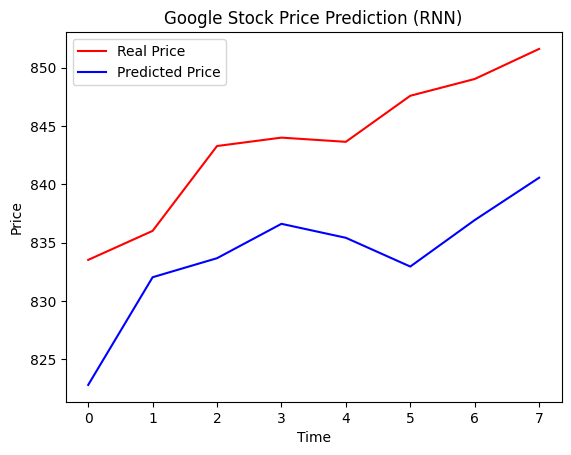

In [68]:

plt.plot(real, color='red', label='Real Price')
plt.plot(predict, color='blue', label='Predicted Price')

plt.title("Google Stock Price Prediction (RNN)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()